In [80]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

from plotting.cell_state_plotters import plot_cell_state_2d, plot_cell_state_3d

In [92]:
# full_q

full_q_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_116.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_117.p", "rb") as f:
   full_q_states.append(pickle.load(f))
	
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_410.p", "rb") as f: 
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_553.p", "rb") as f: 
   full_q_states.append(pickle.load(f))

# q_filter 

q_filter_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_116.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_117.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_410.p", "rb") as f: 
    q_filter_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_553.p", "rb") as f: 
    q_filter_states.append(pickle.load(f))

    


In [36]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [93]:
mode = "normal"

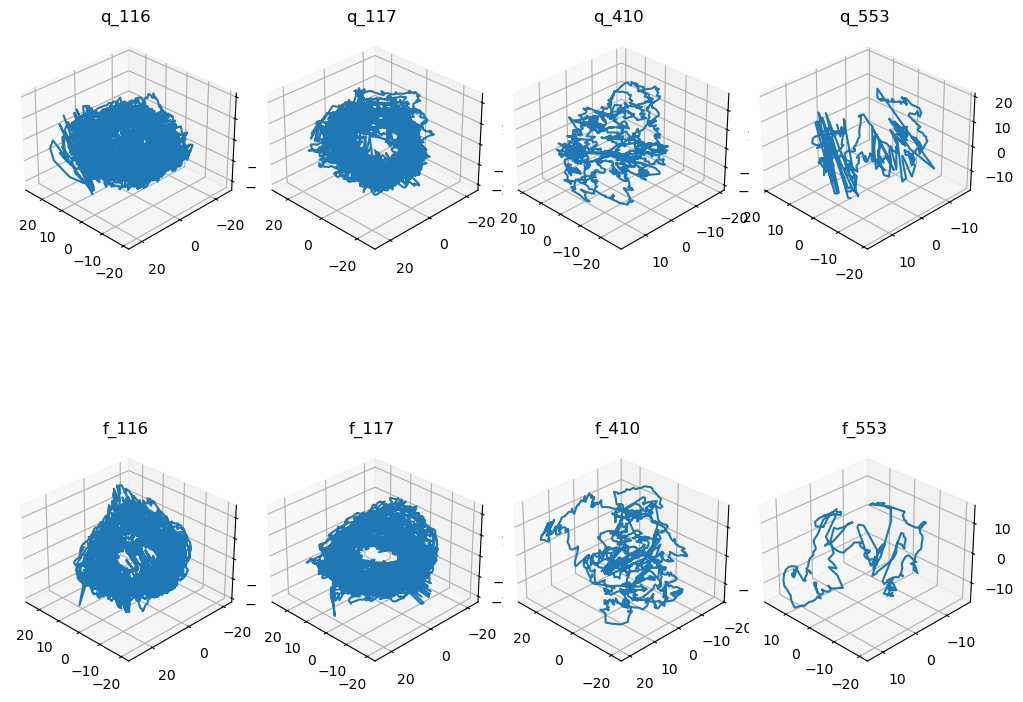

In [102]:
fig, axs = plt.subplots(2,4, figsize=(10,10), subplot_kw={"projection": "3d"})

for ax, array, title in zip(
	axs.ravel(),
	list(map(lambda x: x[mode], full_q_states)) + list(map(lambda x: x[mode], q_filter_states)),
	["q_116", "q_117","q_410", "q_553", "f_116", "f_117", "f_410", "f_553"]):
	
	# Assign every 365 points the same color, to look for seasonal patterns.
	point_colors = np.arange(len(array)) // 365

	plot_cell_state_3d(
		cell_state_array=array,
		ax=ax,
		connect=True,
		ax_view_params={"elev": 30, "azim": 135},
		title=title,
	)

plt.tight_layout()

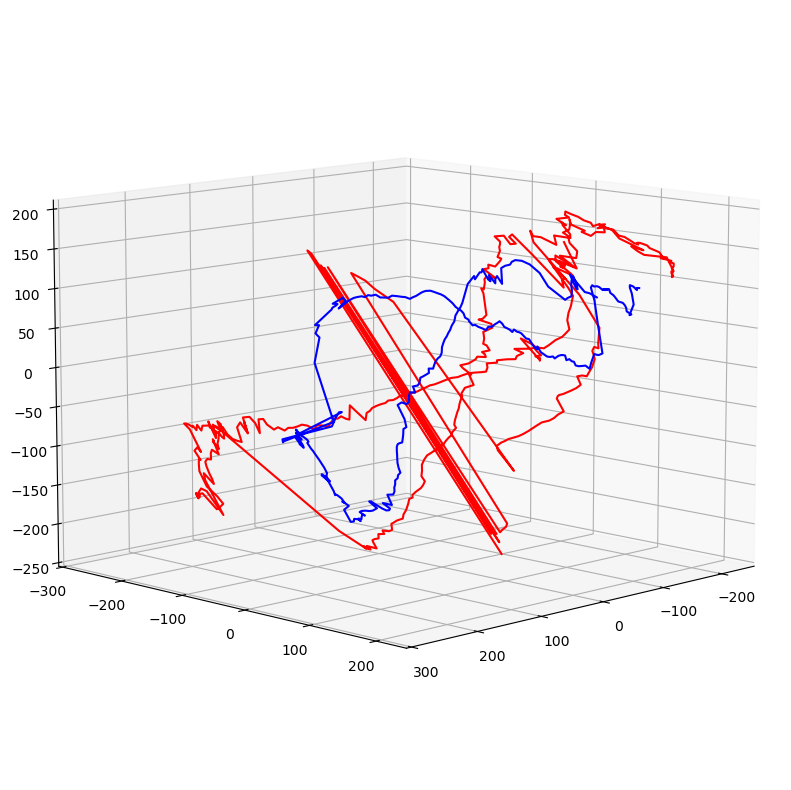

In [45]:
fig, ax = plt.subplots(1,1, figsize=(10,10), subplot_kw={"projection": "3d"})

plot_cell_state_3d(
    cell_state_array=full_q_states[1][mode],
    ax=ax,
    connect=True,
    color="red",
)

plot_cell_state_3d(
    cell_state_array=q_filter_states[1][mode],
    ax=ax,
	connect=True,
    color="blue",
)

ax.view_init(10, 45)

In [109]:

#with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
#    c_full_q = pickle.load(f)


with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states.p", "rb") as f: 
	c_q_filter = pickle.load(f)
    

In [112]:
c_full_q = dict(sorted(c_q_filter.items(), key=lambda item: int(item[0])))


In [113]:
c_means = np.vstack([c_full_q[b]["c_mean"] for b in c_full_q.keys()])
c_m_normal = StandardScaler().fit_transform(c_means)

In [116]:
from scipy.spatial.distance import pdist
dists = pdist(c_m_normal, metric='euclidean')
print(np.max(dists), np.min(dists))


108.84612595047473 1.5015709420095784


In [117]:
mean_mds_3d = MDS(3, verbose=10, normalized_stress=True).fit_transform(c_m_normal)

/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Iteration 0, stress 28006331.1235
Iteration 1, stress 22460491.2569
Iteration 2, stress 20745790.3803
Iteration 3, stress 19839899.6162
Iteration 4, stress 19382995.6195
Iteration 5, stress 19179517.4800
Iteration 6, stress 19058169.0363
Iteration 7, stress 18969008.3680
Iteration 8, stress 18892689.4178
Iteration 9, stress 18821012.9399
Iteration 10, stress 18749389.1569
Iteration 11, stress 18673246.3146
Iteration 12, stress 18587795.3746
Iteration 13, stress 18488502.2424
Iteration 14, stress 18371046.6630
Iteration 15, stress 18231070.7556
Iteration 16, stress 18063822.9810
Iteration 17, stress 17864399.5396
Iteration 18, stress 17627756.8321
Iteration 19, stress 17349052.1475
Iteration 20, stress 17023761.6995
Iteration 21, stress 16648176.9981
Iteration 22, stress 16221527.7740
Iteration 23, stress 15746388.4282
Iteration 24, stress 15228400.5450
Iteration 25, stress 14677983.0759
Iteration 26, stress 14110399.2090
Iteration 27, stress 13541574.0684
Iteration 28, stress 12988859.

In [128]:
strata_ids.value_counts()

0
1    474
2    277
0    108
Name: count, dtype: int64

<Axes3D: >

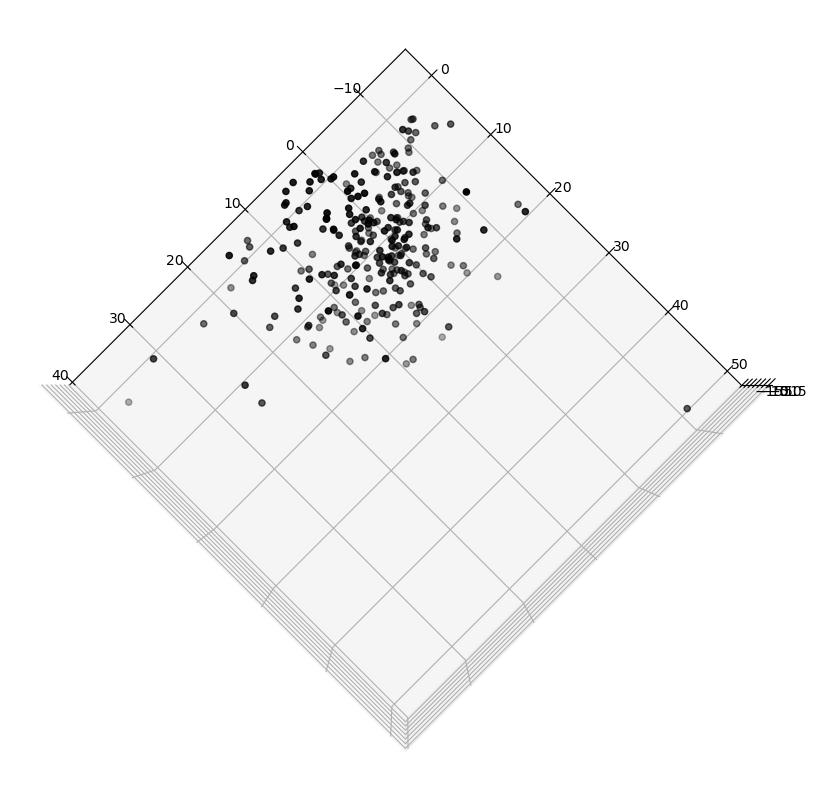

In [132]:
plot_cell_state_3d(mean_mds_3d[strata_ids["0"] == 2], ax_view_params={"elev":90, "azim": 45}, fig_args={"figsize":(10,10)}, c=strata_ids, cmap="coolwarm")

In [ ]:
plot_cell_state_2d(mean_mds_3d)